# Neural net for photo-z 

Following the network structure from multi-task learning.
Originally predict Gaussian mixture model.
Modified to predict a single number based on MSE loss.

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

2026-05-27 03:06:17.665351: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-27 03:06:17.665458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-27 03:06:17.703902: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-27 03:06:17.822182: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-27 03:06:20.497378: W tensorflow/compiler/tf2

In [4]:
#import tensorflow_probability as tfp

In [5]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [6]:
import pandas as pd
import h5py
import numpy as np

## Load training and test data

In [7]:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "train_100k.parquet"
training_data = pd.read_parquet(fname)
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111021 entries, 0 to 111020
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   galaxy_id                   111021 non-null  float64
 1   ra                          111021 non-null  float64
 2   dec                         111021 non-null  float64
 3   sedid                       111021 non-null  int64  
 4   size                        111021 non-null  float64
 5   Ellipticity_1               111021 non-null  float64
 6   Ellipticity_2               111021 non-null  float64
 7   mag_u_lsst                  111021 non-null  float64
 8   mag_g_lsst                  111021 non-null  float64
 9   mag_r_lsst                  111021 non-null  float64
 10  mag_i_lsst                  111021 non-null  float64
 11  mag_z_lsst                  111021 non-null  float64
 12  mag_y_lsst                  111021 non-null  float64
 13  Roman_Y106    

In [8]:
# apply this on test set:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "test_100k.parquet"
test_data = pd.read_parquet(fname)
#test_data.info()

In [9]:
# make X_train, Y_train
col1 = [f'mag_{b}_lsst' for b in 'ugrizy']
col2 = [f'Roman_obs_{b}' for b in ['J129', 'H158']]
col = col1 + col2
X_train = training_data[col]
Y_train = training_data['redshift']

X_test = test_data[col]
Y_test = test_data['redshift']

### Make variants of the training and test data: no NIR, or partial coverage of the NIR bands

In [10]:
def make_missing_bands(data, cols, frac=0.3, seed = 10):
    Ndata = data.shape[0]
    N_noNIR = int(frac*Ndata)
    np.random.seed(seed)
    ind = np.random.choice(np.arange(Ndata), size=N_noNIR, replace=False)
    X_train_missing = data.copy()
    X_train_missing.loc[ind, cols] = np.nan
    return X_train_missing

In [12]:
X_train_noNIR = X_train.drop(columns=['Roman_obs_J129', 'Roman_obs_H158'])
X_test_noNIR = X_test.drop(columns=['Roman_obs_J129', 'Roman_obs_H158'])

# 30% data without NIR bands # Let's leave this scenario to later!
cols = ['Roman_obs_J129', 'Roman_obs_H158']
X_train_missing = make_missing_bands(X_train, cols, frac=0.3, seed=10)
X_test_missing = make_missing_bands(X_test, cols, frac=0.3, seed=5)
# notice in NN scenario this partial coverage case is not easily dealt with
# if something is not detected, we can assign it a cap value (e.g. the magnitude limit)
# however, if something has not been observed (e.g. not in overlap Roman), then 
# we will need a separate indicator for the network to learn that it is absent, rather than too small
# which means we need to bump the input into shape (2, 8), with a channel indicating if there is observation in that band

# predefined functions & variables

In [13]:
#Functions to plot: bias, sigma, outlier fraction:
#Functions to produce these quantities as functin of mag
#from astropy.stats import biweight_location, biweight_scale
from scipy.stats import sigmaclip

def get_biweight_mean_sigma_outlier(subset, nclip= 3, abs_out_thresh=0.2):
    subset_clip, _, _ = sigmaclip(subset, low=3, high=3)
    for _j in range(nclip):
        subset_clip, _, _ = sigmaclip(subset_clip, low=3, high=3)

    #mean = biweight_location(subset_clip)
    #std = biweight_scale(subset_clip)
    mean = np.mean(subset_clip)
    std = np.std(subset_clip)
    #outlier_rate = np.sum(np.abs(subset) > 3 * biweight_scale(subset_clip)) / len(
    #    subset
    #)
    outlier_rate = np.sum(np.abs(subset) > 3 * np.std(subset_clip)) / len(
        subset
    )
    abs_outlier_rate = np.sum(np.abs(subset) > abs_out_thresh) / len(
        subset
    )

    return (
        mean,
        std / np.sqrt(len(subset_clip)),
        std,
        outlier_rate,
        abs_outlier_rate,
    )

In [25]:
import pickle

def get_all_stats(y_train, y_pred, imag_data, save=True, saveroot="", redshift_bins = np.linspace(0,2.5,11), imag_bins = np.linspace(18, 25.5,11)):
    Y = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y)/(1+Y)
    stats = get_biweight_mean_sigma_outlier(dz, nclip= 3, abs_out_thresh=0.2)

    # split in terms of i-mags and redshifts
    redshift_stats = []
    imag_stats = []
    for i in range(10):
        ind= (Y > redshift_bins[i]) & (Y < redshift_bins[i+1])
        redshift_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))
        ind= (imag_data > imag_bins[i]) & (imag_data < imag_bins[i+1])
        imag_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))

    if save == True:
        with open(saveroot, "wb") as f:
            pickle.dump([stats, redshift_stats, imag_stats], f)

    return stats, redshift_stats, imag_stats

def read_stats(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    stats, redshift_stats, imag_stats = data
    return stats, redshift_stats, imag_stats

In [26]:
def plot_stats(stats, redshift_stats, imag_stats, y_train, y_pred, redshift_bins, imag_bins, i_mag_data):

    Y = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y)/(1+Y)

    fig,axarr=plt.subplots(1,figsize=(8,8))

    plt.scatter(y_train, y_pred, s=0.1, color='k')
    plt.plot([0,2.5],[0,2.5],'r-')
    plt.ylabel('predicted redshift')
    plt.xlabel('truth redshift')
    plt.xlim([0,2.5])
    plt.ylim([0,2.5])
    
    mean, _mean_err, std, outlier_rate, abs_outlier_rate = stats
    mean, std, outlier_rate, abs_outlier_rate = (
                round(mean, 4),
                round(std, 4),
                round(outlier_rate, 4),
                round(abs_outlier_rate, 4),
            )
    
    plt.plot([0,2.5],[0- 3 * std, 2.5-3*std], 'r--')
    plt.plot([0,2.5],[0+ 3 * std, 2.5+3*std], 'r--')
    
    abs_out_thresh=0.2
    label=rf"$\Delta z = {mean} $" + "\n"  + rf"$\sigma z = {std} $"  + "\n"  + rf"outlier rate (>3$\sigma$) = {outlier_rate}"  + "\n" + f"outlier rate (>{abs_out_thresh}) = {abs_outlier_rate}"
    
    plt.text(0.1,1.5, label, fontsize=14)

    fig,axarr=plt.subplots(2,figsize=(8,8),sharex=True)

    N_bin = len(redshift_bins) - 1

    plt.sca(axarr[0])
    mean = np.zeros(N_bin)
    _mean_err = np.zeros(N_bin)
    std = np.zeros(N_bin)
    outlier_rate = np.zeros(N_bin)
    abs_outlier = np.zeros(N_bin)
    for i in range(N_bin):
      mean[i], _mean_err[i], std[i], outlier_rate[i], abs_outlier[i] = redshift_stats[i]
    
    plt.plot((redshift_bins[1:] + redshift_bins[:-1])/2, mean, '-',label="bias")
    plt.plot((redshift_bins[1:] + redshift_bins[:-1])/2, std, '-',label="$\sigma_z$")
    plt.plot((redshift_bins[1:] + redshift_bins[:-1])/2, outlier_rate, '-',label="outlier rate")
    plt.legend()
    plt.ylabel("statistics")
    
    plt.sca(axarr[1])
    plt.scatter(Y, dz, s=0.1, color='k')
    plt.xlabel("redshifts")
    plt.ylabel("$(z_{pred} - z_{true})/(1 + z_{true})$")
    
    plt.subplots_adjust(hspace=0)

    fig,axarr=plt.subplots(2,figsize=(8,8),sharex=True)

    N_bin = len(imag_bins) - 1

    plt.sca(axarr[0])
    mean = np.zeros(N_bin)
    _mean_err = np.zeros(N_bin)
    std = np.zeros(N_bin)
    outlier_rate = np.zeros(N_bin)
    abs_outlier = np.zeros(N_bin)
    for i in range(N_bin):
        mean[i], _mean_err[i], std[i], outlier_rate[i], abs_outlier[i] = imag_stats[i]
    
    plt.plot((imag_bins[1:] + imag_bins[:-1])/2, mean, '-',label="bias")
    plt.plot((imag_bins[1:] + imag_bins[:-1])/2, std, '-',label="$\sigma_z$")
    plt.plot((imag_bins[1:] + imag_bins[:-1])/2, outlier_rate, '-',label="outlier rate")
    plt.legend()
    plt.ylabel("statistics")
    
    plt.sca(axarr[1])
    plt.scatter(i_mag_data, dz, s=0.1, color='k')
    plt.xlabel("i magnitude")
    plt.ylabel("$(z_{pred} - z_{true})/(1 + z_{true})$")
    
    plt.subplots_adjust(hspace=0)

In [48]:
def stats_to_markdown(stats1_input, stats2_input, labels=("Mean", "Mean err", "Std", "Outlier rate", "Abs outlier rate"), skip_indices=(1,),
                     data_title=("Dataset 1", "Dataset 2")):
    # 0. Filter out skipped indices
    keep = [i for i in range(len(stats1_input)) if i not in skip_indices]
    stats1 = [stats1_input[i] for i in keep]
    stats2 = [stats2_input[i] for i in keep]
    labels = [labels[i] for i in keep]
    
    # 1. Fractional change vs dataset 1
    pct_change = [100 * (s2 - s1) / s1 if s1 != 0 else float('nan')
                  for s1, s2 in zip(stats1, stats2)]
    
    # 3. Build rows, rounded to 3 digits
    rows = []
    for label, s1, s2, pc in zip(labels, stats1, stats2, pct_change):
        rows.append(f"| {label} | {s1:.3g} | {s2:.3g} | {pc:.3g}% |")
    
    # 4. Assemble Markdown
    md = (
        f"| Statistic | {data_title[0]} | {data_title[1]} | % change |\n"
        "|---|---:|---:|---:|\n"
        + "\n".join(rows)
    )
    return md

In [59]:
def compare_binned_stats(redshift_bins, imag_bins, redshift_stats1, imag_stats1, redshift_stats2, imag_stats2):
    fig,axarr=plt.subplots(1, 2,figsize=(10,4))

    xlabels=["redshifts", "i magnitude"]

    for j, bins, stats1, stats2 in zip([0,1], [redshift_bins, imag_bins], 
                                      [redshift_stats1, imag_stats1], [redshift_stats2, imag_stats2]):
        plt.sca(axarr[j])
        N_bin = len(bins) - 1
        xx = (bins[1:] + bins[:-1])/2
        
        mean1 = np.zeros(N_bin)
        std1 = np.zeros(N_bin)
        outlier_rate1 = np.zeros(N_bin)
        for i in range(N_bin):
          mean1[i], _, std1[i], outlier_rate1[i], _ = stats1[i]
    
    
        mean2 = np.zeros(N_bin)
        std2 = np.zeros(N_bin)
        outlier_rate2 = np.zeros(N_bin)
        for i in range(N_bin):
          mean2[i], _, std2[i], outlier_rate2[i], _ = stats2[i]
        
        plt.plot(xx, mean1, '-',label="bias", color="C0")
        plt.plot(xx, std1, '-',label="$\sigma_z$", color="C1")
        plt.plot(xx, outlier_rate1, '-',label="outlier rate", color="C2")

        plt.plot(xx, mean2, '--', color="C0")
        plt.plot(xx, std2, '--', color="C1")
        plt.plot(xx, outlier_rate2, '--', color="C2")
        plt.legend()
        plt.ylabel("statistics")
        plt.xlabel(xlabels[j])
        plt.grid()
    plt.tight_layout()

### model related

In [11]:
batch_size=64
steps_per_epoch = len(X_train) // batch_size  # e.g. 1000 samples / 64 = 15 steps

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=50 * steps_per_epoch,   # 50 epochs worth of steps
    decay_rate=0.1,
    staircase=True
)

# Make a network structure for single task learning, only focusing on photo-z

Following https://arxiv.org/pdf/2209.10161

In [12]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

input_= tf.keras.layers.Input(shape=[8])  # 6 band LSST data + JH Roamn
norm_layer = tf.keras.layers.Normalization() # normalization
norm_ = norm_layer(input_)

hidden1 = tf.keras.layers.Dense(100, activation="relu")(norm_)
hidden1 = tf.keras.layers.Dropout(0.02)(hidden1)
hidden2 = tf.keras.layers.Dense(150, activation="relu")(hidden1)
hidden2 = tf.keras.layers.Dropout(0.02)(hidden2)
hidden3 = tf.keras.layers.Dense(200, activation="relu")(hidden2)
hidden3 = tf.keras.layers.Dropout(0.02)(hidden3)
hidden4 = tf.keras.layers.Dense(150, activation="relu")(hidden3)
hidden4 = tf.keras.layers.Dropout(0.02)(hidden4)
hidden5 = tf.keras.layers.Dense(100, activation="relu")(hidden4)
hidden5 = tf.keras.layers.Dropout(0.02)(hidden5)
hidden6 = tf.keras.layers.Dense(50, activation="relu")(hidden5)

#mdn_out = tf.keras.layers.Dense(N_COMPONENTS * 3)(hidden6)
mdn_out = tf.keras.layers.Dense(1)(hidden6)

model = tf.keras.Model(inputs=input_,
                       outputs=mdn_out)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

2026-05-26 06:56:34.668641: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20849 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [13]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 8)]               0         
                                                                 
 normalization (Normalizati  (None, 8)                 17        
 on)                                                             
                                                                 
 dense (Dense)               (None, 100)               900       
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense_1 (Dense)             (None, 150)               15150     
                                                                 
 dropout_1 (Dropout)         (None, 150)               0         
                                                             

In [17]:
norm_layer.adapt(X_train.to_numpy())
X_train_use = X_train.to_numpy()
Y_train_mdn_use = Y_train.to_numpy()
Y_train_mdn_use = Y_train_mdn_use.reshape(len(Y_train_mdn_use), 1)

history = model.fit(X_train_use, Y_train_mdn_use, epochs=30, batch_size=batch_size, validation_split=0.2)

Epoch 1/30


2026-05-26 10:00:29.474303: I external/local_xla/xla/service/service.cc:168] XLA service 0x7faaac717a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-26 10:00:29.474330: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2026-05-26 10:00:29.518766: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-26 10:00:29.609581: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903
I0000 00:00:1779814829.863436   21622 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1388/1388 [==============================] - 22s 12ms/step - loss: 0.0170 - mae: 0.0753 - val_loss: 0.0044 - val_mae: 0.0368
Epoch 2/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0046 - mae: 0.0405 - val_loss: 0.0055 - val_mae: 0.0368
Epoch 3/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0039 - mae: 0.0362 - val_loss: 0.0019 - val_mae: 0.0236
Epoch 4/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0033 - mae: 0.0330 - val_loss: 0.0027 - val_mae: 0.0297
Epoch 5/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0036 - mae: 0.0346 - val_loss: 0.0032 - val_mae: 0.0392
Epoch 6/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0027 - mae: 0.0302 - val_loss: 0.0011 - val_mae: 0.0186
Epoch 7/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0030 - mae: 0.0314 - val_loss: 0.0026 - val_mae: 0.0384
Epoch 8/30
1388/1388 [==============================] - 17s

<Axes: xlabel='Epoch'>

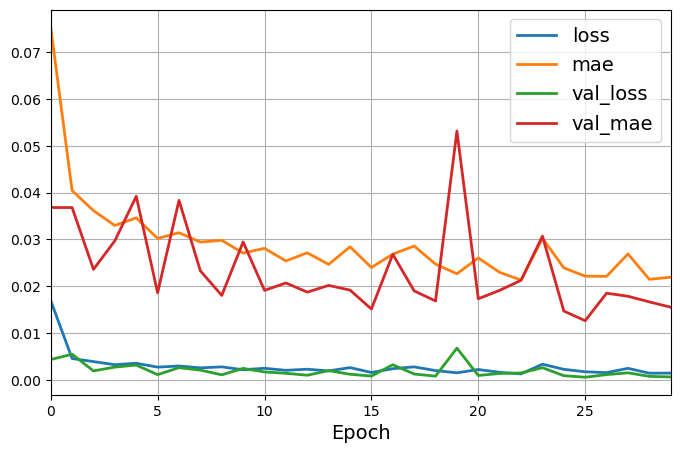

In [18]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0,29],
    linewidth=2,
    grid=True,
    xlabel='Epoch',
)

In [19]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model.save(root + 'basic_NN.model.keras')

# Save normalisation parameters alongside it
#np.save(root + 'basic_CNN.norm_params.npy', {
#    'Y_mean': Y_mean, 'Y_std': Y_std
#})

## Load the trained model

In [17]:
# read in this model:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model = tf.keras.models.load_model(root + 'basic_NN.model.keras')

2026-05-27 03:41:46.151192: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20737 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [18]:
# apply on the training/test data
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

3470/3470 [==============================] - 18s 5ms/step


In [28]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
saveroot = root + "basic_NN.stats-train.pkl"
stats1, redshift_stats1, imag_stats1 = get_all_stats(Y_train, y_pred_train, training_data['mag_i_lsst'], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

saveroot = root + "basic_NN.stats-test.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test, y_pred_test, test_data['mag_i_lsst'], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

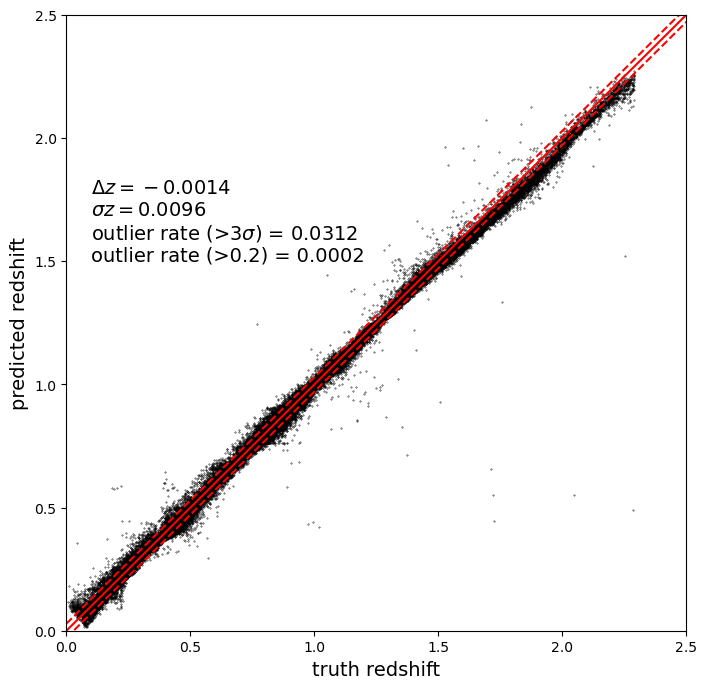

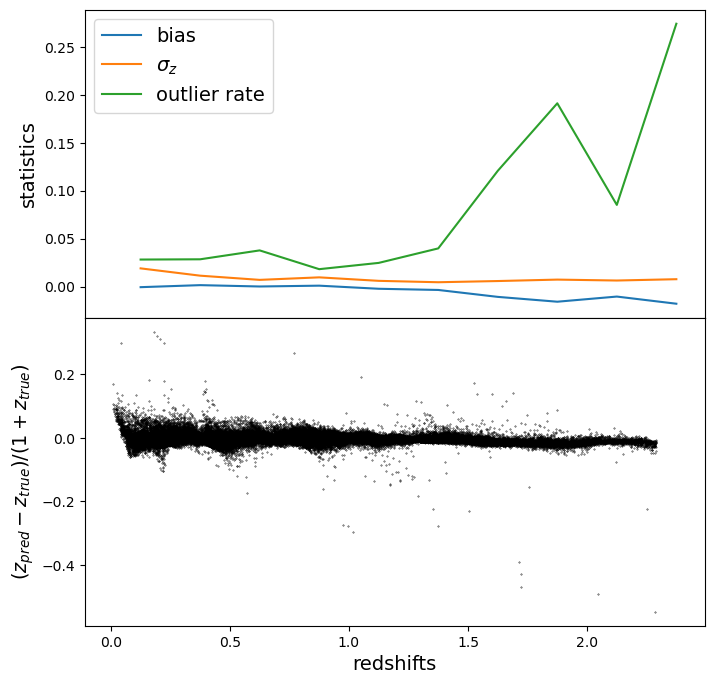

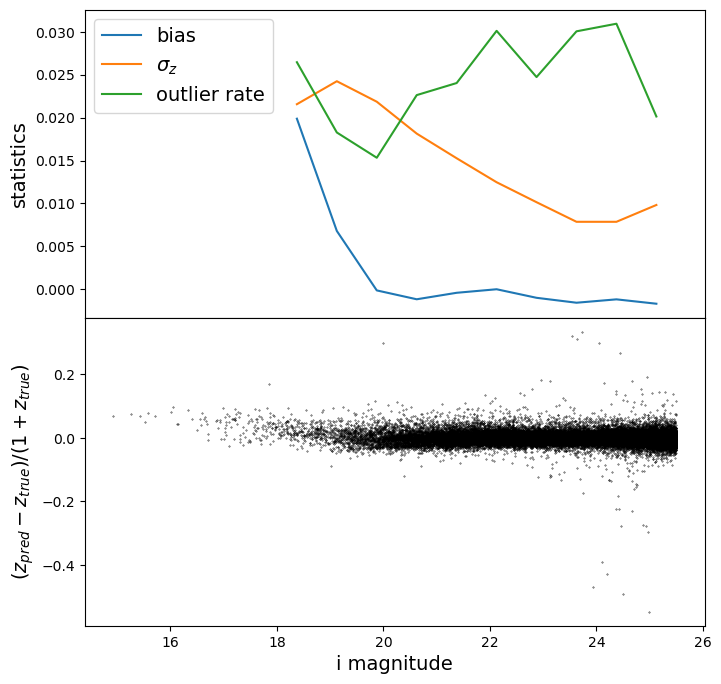

In [29]:
#training
plot_stats(stats1, redshift_stats1, imag_stats1, Y_train, y_pred_train, redshift_bins, imag_bins, training_data['mag_i_lsst'])

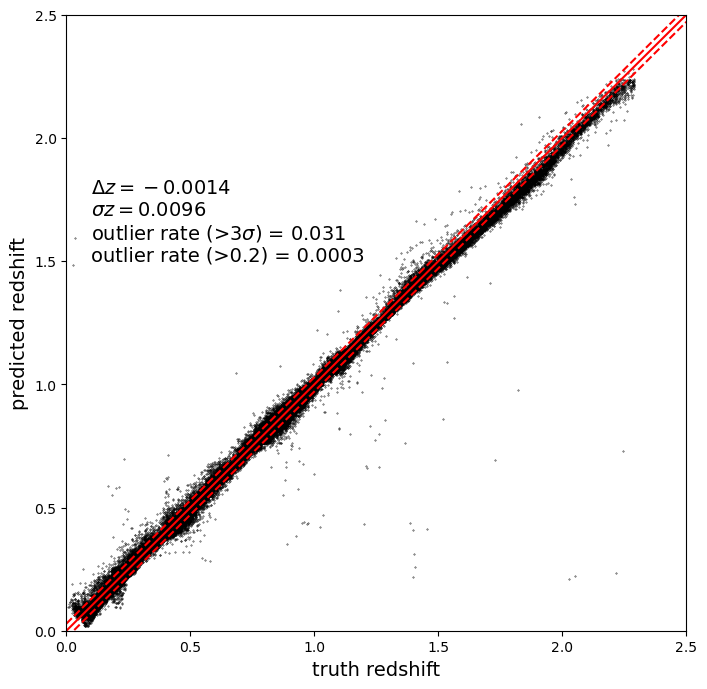

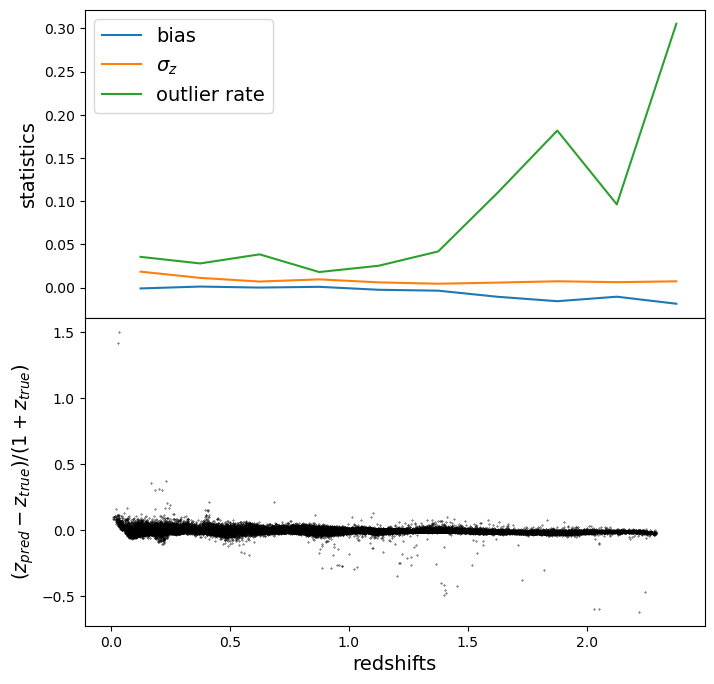

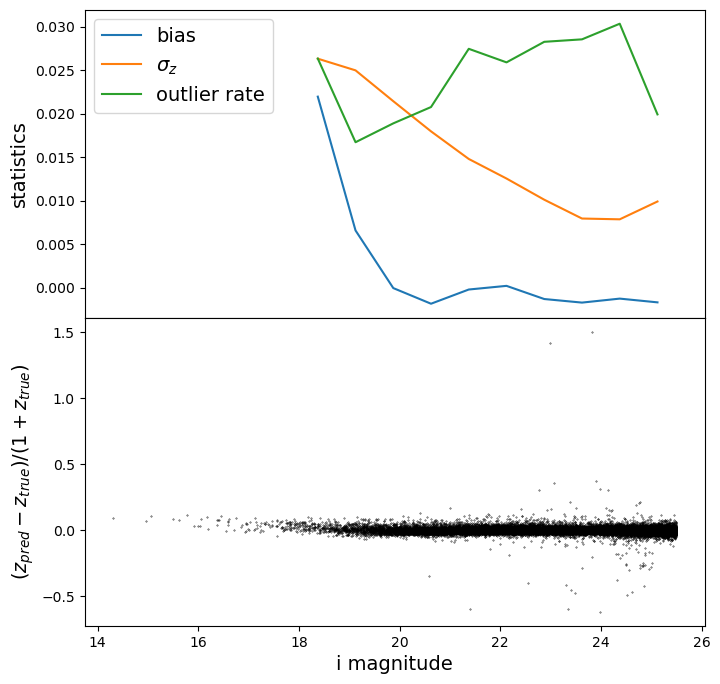

In [30]:
#training
plot_stats(stats2, redshift_stats2, imag_stats2, Y_test, y_pred_test, redshift_bins, imag_bins, test_data['mag_i_lsst'])

### Remove some of the NIR bands

- Remove nir completely
- Keep some nir, use a placeholder for no-detection

In [37]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

input_= tf.keras.layers.Input(shape=[6])  # 6 band LSST data
norm_layer = tf.keras.layers.Normalization() # normalization
norm_ = norm_layer(input_)

hidden1 = tf.keras.layers.Dense(100, activation="relu")(norm_)
hidden1 = tf.keras.layers.Dropout(0.02)(hidden1)
hidden2 = tf.keras.layers.Dense(150, activation="relu")(hidden1)
hidden2 = tf.keras.layers.Dropout(0.02)(hidden2)
hidden3 = tf.keras.layers.Dense(200, activation="relu")(hidden2)
hidden3 = tf.keras.layers.Dropout(0.02)(hidden3)
hidden4 = tf.keras.layers.Dense(150, activation="relu")(hidden3)
hidden4 = tf.keras.layers.Dropout(0.02)(hidden4)
hidden5 = tf.keras.layers.Dense(100, activation="relu")(hidden4)
hidden5 = tf.keras.layers.Dropout(0.02)(hidden5)
hidden6 = tf.keras.layers.Dense(50, activation="relu")(hidden5)

#mdn_out = tf.keras.layers.Dense(N_COMPONENTS * 3)(hidden6)
mdn_out = tf.keras.layers.Dense(1)(hidden6)

model = tf.keras.Model(inputs=input_,
                       outputs=mdn_out)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

In [38]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 6)]               0         
                                                                 
 normalization (Normalizati  (None, 6)                 13        
 on)                                                             
                                                                 
 dense (Dense)               (None, 100)               700       
                                                                 
 dropout (Dropout)           (None, 100)               0         
                                                                 
 dense_1 (Dense)             (None, 150)               15150     
                                                                 
 dropout_1 (Dropout)         (None, 150)               0         
                                                             

In [39]:
norm_layer.adapt(X_train_noNIR.to_numpy())
X_train_use = X_train_noNIR.to_numpy()
Y_train_mdn_use = Y_train.to_numpy()
Y_train_mdn_use = Y_train_mdn_use.reshape(len(Y_train_mdn_use), 1)

history = model.fit(X_train_use, Y_train_mdn_use, epochs=30, batch_size=batch_size, validation_split=0.2)

Epoch 1/30
1388/1388 [==============================] - 19s 13ms/step - loss: 0.0301 - mae: 0.1010 - val_loss: 0.0122 - val_mae: 0.0608
Epoch 2/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0095 - mae: 0.0555 - val_loss: 0.0060 - val_mae: 0.0427
Epoch 3/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0072 - mae: 0.0461 - val_loss: 0.0041 - val_mae: 0.0324
Epoch 4/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0062 - mae: 0.0422 - val_loss: 0.0045 - val_mae: 0.0350
Epoch 5/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0054 - mae: 0.0387 - val_loss: 0.0029 - val_mae: 0.0287
Epoch 6/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0050 - mae: 0.0369 - val_loss: 0.0035 - val_mae: 0.0255
Epoch 7/30
1388/1388 [==============================] - 17s 12ms/step - loss: 0.0047 - mae: 0.0359 - val_loss: 0.0107 - val_mae: 0.0542
Epoch 8/30
1388/1388 [==========================

<Axes: xlabel='Epoch'>

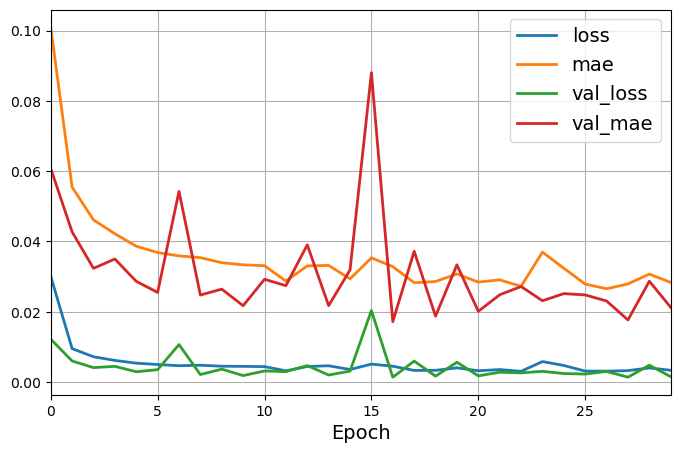

In [40]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0,29],
    linewidth=2,
    grid=True,
    xlabel='Epoch',
)

In [41]:
# save the model:

# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model.save(root + 'basic_NN_missing_NIR_.model.keras')

In [31]:
# load the model:
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
model = tf.keras.models.load_model(root + 'basic_NN_missing_NIR_.model.keras')

In [32]:
# apply on the training/test data
y_pred_train = model.predict(X_train_noNIR)
y_pred_test = model.predict(X_test_noNIR)

3470/3470 [==============================] - 18s 5ms/step


In [33]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
root = "/pscratch/sd/q/qhang/cnnpz/cardinal/models/"
saveroot = root + "basic_NN_missing_NIR.stats-train.pkl"
stats3, redshift_stats3, imag_stats3 = get_all_stats(Y_train, y_pred_train, training_data['mag_i_lsst'], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

saveroot = root + "basic_NN_missing_NIR.stats-test.pkl"
stats4, redshift_stats4, imag_stats4 = get_all_stats(Y_test, y_pred_test, test_data['mag_i_lsst'], save=True, saveroot=saveroot, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

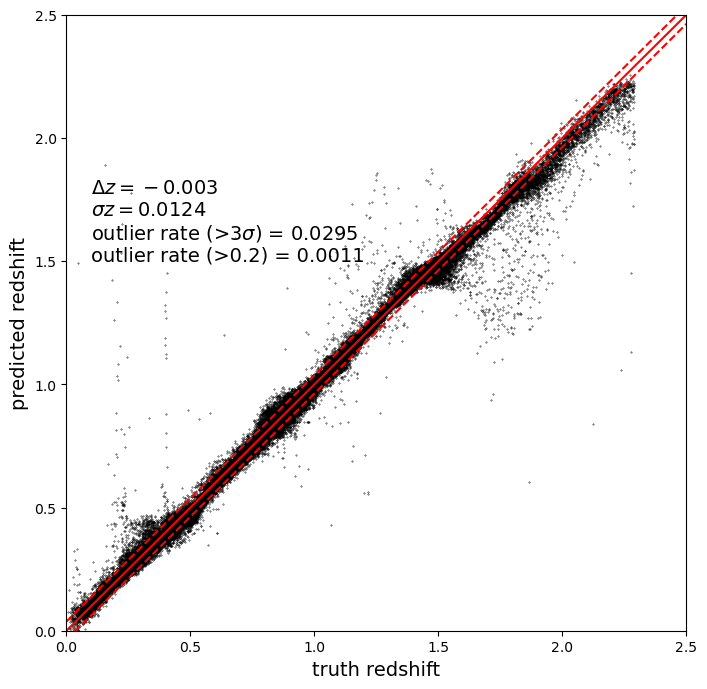

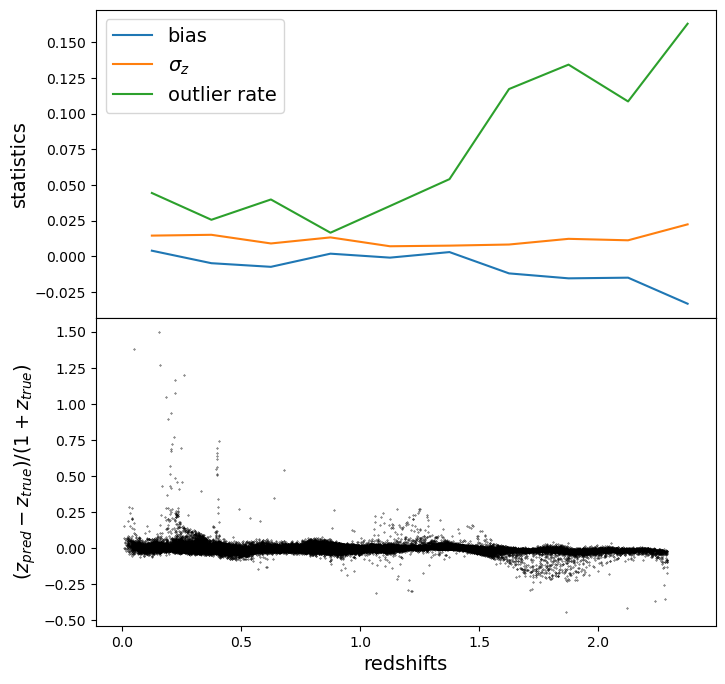

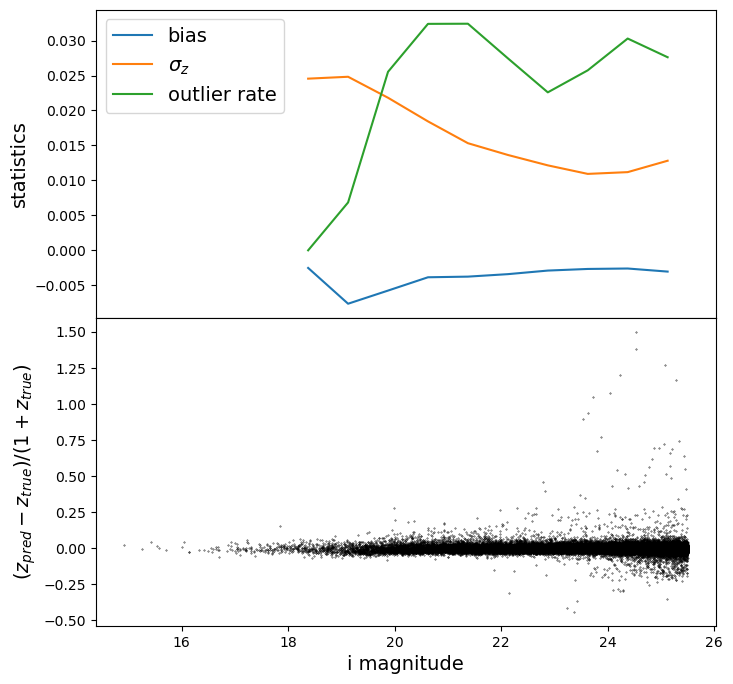

In [34]:
plot_stats(stats3, redshift_stats3, imag_stats3, Y_train, y_pred_train, redshift_bins, imag_bins, training_data['mag_i_lsst'])

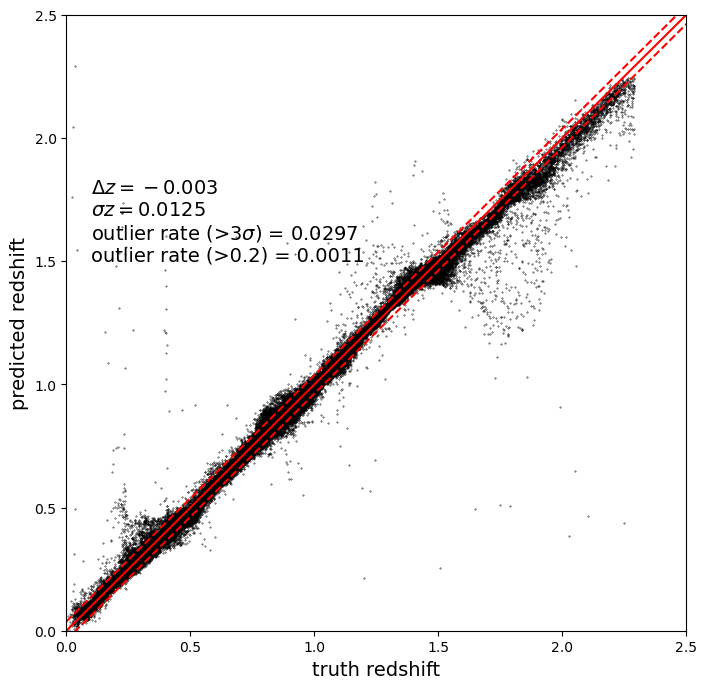

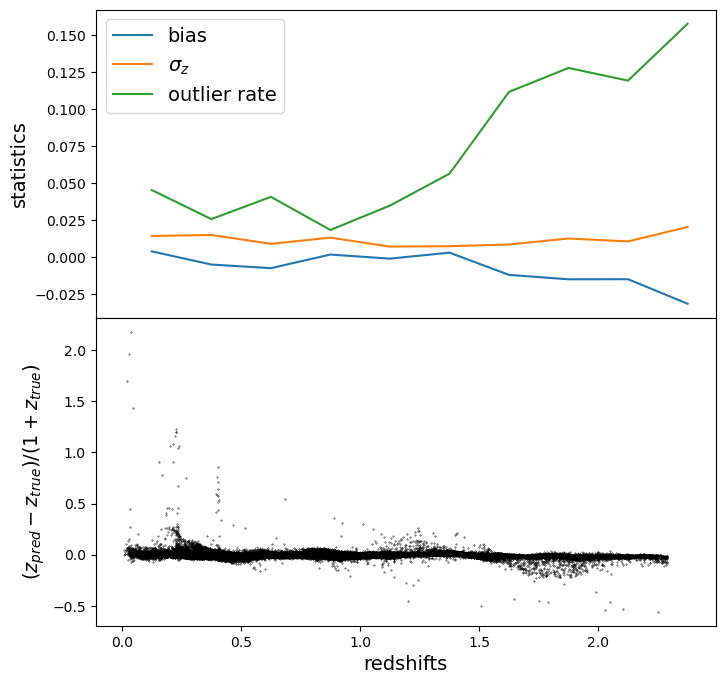

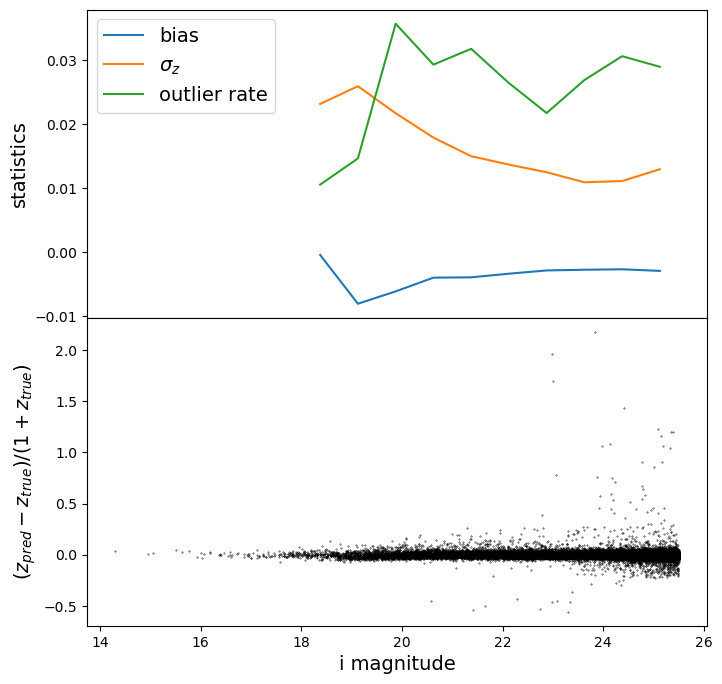

In [35]:
plot_stats(stats4, redshift_stats4, imag_stats4, Y_test, y_pred_test, redshift_bins, imag_bins, test_data['mag_i_lsst'])

# Compare the stats

In [39]:
from IPython.display import Markdown, display

In [49]:
md = stats_to_markdown(stats2, stats4, labels=("Mean", "Mean err", "Std", "Outlier rate", "Abs outlier rate"), skip_indices=(1,),
                      data_title=("ugrizyJH","ugrizy"))
display(Markdown(md))

| Statistic | ugrizyJH | ugrizy | % change |
|---|---:|---:|---:|
| Mean | -0.00144 | -0.00297 | 106% |
| Std | 0.00957 | 0.0125 | 30.1% |
| Outlier rate | 0.031 | 0.0297 | -4.25% |
| Abs outlier rate | 0.000342 | 0.00108 | 216% |

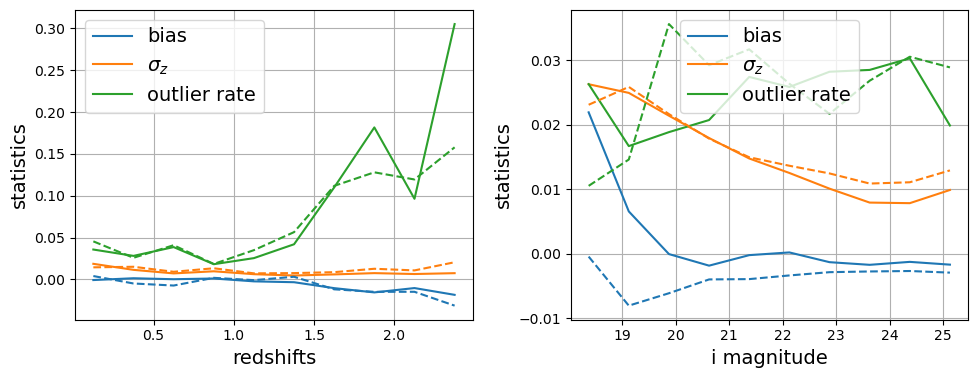

In [60]:
# now also compare changes in bins of redhsifts and imag:

compare_binned_stats(redshift_bins, imag_bins, redshift_stats2, imag_stats2, redshift_stats4, imag_stats4)